<div style="
  background: linear-gradient(135deg, #1a1a2e 0%, #0f0f1a 100%);
  padding: 20px 28px 20px 28px;
  border-radius: 20px;
  font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
  box-shadow: 0 8px 24px rgba(0,0,0,0.5);
  border: 1px solid #818285;
  max-width: 66%;
">
  <div style="display: flex; align-items: center; gap: 14px; margin-bottom: 16px;">
    <svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" width="100" height="100" viewBox="0 0 100 100">
        <image xlink:href="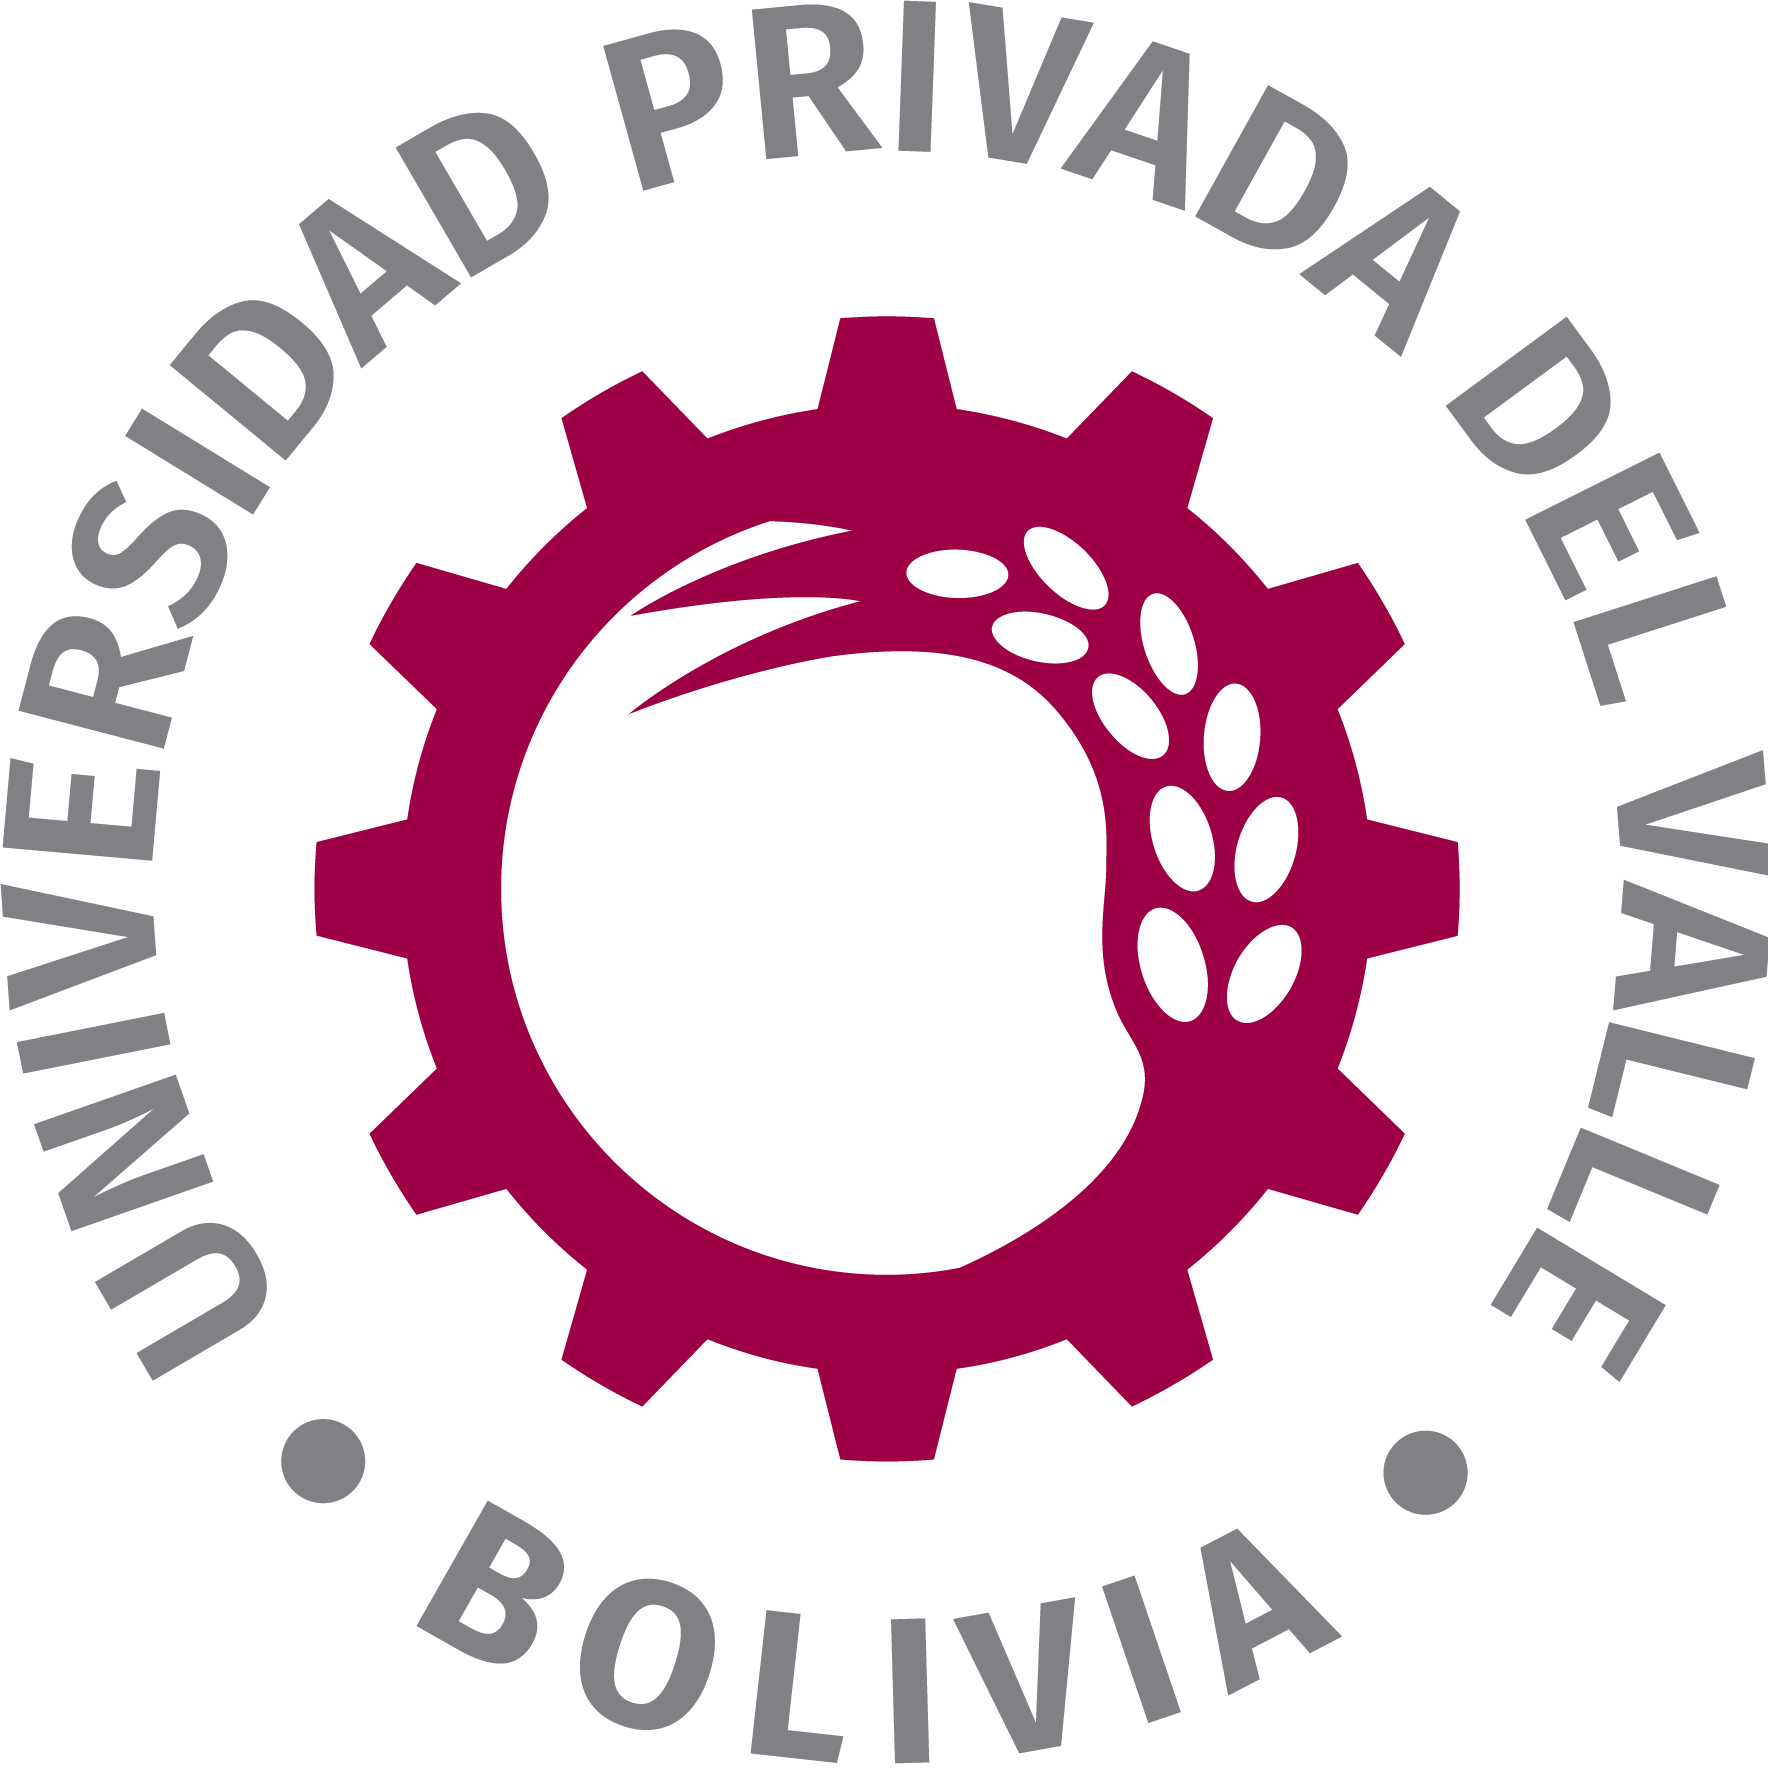" x="0" y="0" width="100" height="100"/>
    </svg>
    <div style="flex:1">
      <div style="color: #b80144; font-weight: 700; font-size: 1.3rem; letter-spacing: -0.2px;">Diplomado Big Data, Analytics y BI v1</div>
      <div style="color: #818285; font-size: 0.75rem;">Business Intelligence y Modelos Predictivos</div>
    </div>
    <div style="display: flex; gap: 20px;">
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Docente</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Mauricio Rada Salas</div>
      </div>
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Fecha</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Junio 2026</div>
      </div>
    </div>
  </div>
  <div style="height: 1px; background: linear-gradient(90deg, #818285, #b80144, #818285); margin: 12px 0 18px 0;"></div>
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: space-between;">
    <div style="display: flex; gap: 12px; flex-wrap: wrap; width: 100%; justify-content: flex-start;">
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👨‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">ILIAN JOSEPH FELIPEZ VACA</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👩‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">MARCELO FAVIO NINA CALSINA</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👨‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">PAOLA MELANI QUISPE MAMANI</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👩‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">MIGUEL ANGEL MOLLERICONA CUENTAS</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
    </div>
  </div>
</div>

# Análisis Predictivo de Churn — Telco Customer Churn (BlastChar / Kaggle)
**Objetivo de negocio:** identificar clientes con alta probabilidad de fuga (*churn*) para diseñar campañas de retención dirigidas, maximizando el *Recall* de la clase fuga.

Dataset: [Telco Customer Churn — BlastChar (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [32]:
# Librerías generales
import warnings

warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay,
)

sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Proceso ETL (Extracción, Transformación y Limpieza)

In [33]:
# --- EXTRACCIÓN: Kaggle (opendatasets/kagglehub) o carga local ---
FILENAME = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

def cargar_dataset(filename=FILENAME):
    """Detecta automáticamente la fuente del dataset:
    1) Archivo local en data/raw/ (estructura del proyecto)
    2) Archivo local en el entorno (subido manualmente o vía files.upload())
    3) Descarga desde Kaggle usando kagglehub
    4) Descarga desde Kaggle usando opendatasets (requiere kaggle.json)
    """
    # 1) Buscar el archivo en la estructura del proyecto (data/raw/)
    posibles_rutas = [
        f'data/raw/{filename}',                    # Desde la raíz del proyecto
        f'../data/raw/{filename}',                 # Desde notebooks/
        f'../../data/raw/{filename}',              # Desde subcarpetas más profundas
        filename,                                   # Directorio actual
        f'/content/data/raw/{filename}',           # En Colab
        f'/content/{filename}'                     # Root de Colab
    ]
    
    for ruta in posibles_rutas:
        if os.path.exists(ruta):
            print(f'Dataset encontrado localmente en: {ruta}')
            return pd.read_csv(ruta)

    # 2) Intentar carga interactiva en Colab (files.upload)
    try:
        from google.colab import files
        print('Archivo no encontrado localmente. Sube el CSV manualmente:')
        uploaded = files.upload()
        ruta = list(uploaded.keys())[0]
        return pd.read_csv(ruta)
    except ImportError:
        pass

    # 3) Intentar descarga automática desde Kaggle con kagglehub
    try:
        import kagglehub
        print('Descargando dataset desde Kaggle (kagglehub)...')
        path = kagglehub.dataset_download('blastchar/telco-customer-churn')
        for root, _, files_ in os.walk(path):
            for f in files_:
                if f.endswith('.csv'):
                    return pd.read_csv(os.path.join(root, f))
    except Exception as e:
        print(f'kagglehub no disponible o falló: {e}')

    # 4) Intentar descarga automática desde Kaggle con opendatasets
    try:
        import opendatasets as od
        print('Descargando dataset desde Kaggle (opendatasets)...')
        od.download('https://www.kaggle.com/datasets/blastchar/telco-customer-churn')
        for root, _, files_ in os.walk('.'):
            for f in files_:
                if f.endswith('.csv') and 'Telco' in f:
                    return pd.read_csv(os.path.join(root, f))
    except Exception as e:
        print(f'opendatasets no disponible o falló: {e}')

    raise FileNotFoundError('No se pudo cargar el dataset por ningún método disponible.')

df = cargar_dataset()
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()


Dataset encontrado localmente en: ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset cargado: 7043 filas x 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# --- TRANSFORMACIÓN Y LIMPIEZA ---

# Eliminación de identificador (no aporta valor predictivo)
df = df.drop(columns=['customerID'])

# Limpieza crítica de TotalCharges: convertir a numérico, forzando NaN en espacios en blanco
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_nulos = df['TotalCharges'].isnull().sum()
print(f'Valores nulos detectados en TotalCharges tras conversión: {n_nulos}')

# Imputación con la mediana
mediana_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_total_charges)
print(f'Imputados con la mediana ({mediana_total_charges:.2f}).')

# Verificación de nulos después de imputación
print(f'Valores nulos totales después de imputación: {df.isnull().sum().sum()}')


Valores nulos detectados en TotalCharges tras conversión: 11
Imputados con la mediana (1397.47).
Valores nulos totales después de imputación: 0


In [35]:
# --- CODIFICACIÓN DE VARIABLES ---

# Variables binarias: LabelEncoder
columnas_binarias = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]
encoders = {}
for col in columnas_binarias:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Variables categóricas multi-clase: one-hot encoding (drop_first evita colinealidad)
columnas_multiclase = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]
df = pd.get_dummies(df, columns=columnas_multiclase, drop_first=True, dtype=int)

# SeniorCitizen ya es binaria numérica (0/1) en el dataset original
print(f"\nDimensiones tras codificación: {df.shape}")

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}
Churn: {'No': np.int64(0), 'Yes': np.int64(1)}

Dimensiones tras codificación: (7043, 31)


In [31]:
# ==================== 5. VERIFICACIÓN FINAL Y GUARDADO ====================
# --- VERIFICACIÓN FINAL ---
nulos_restantes = df.isnull().sum().sum()
print(f"Valores nulos restantes en el dataset: {nulos_restantes}")
print(
    f"Dimensiones finales del dataset analítico: {df.shape[0]} registros x {df.shape[1]} variables"
)
df.head()

# Guardar dataset limpio en data/processed/ (desde cualquier ubicación)
# Obtener la ruta del proyecto (subir desde notebooks/ si es necesario)
current_dir = os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

processed_dir = os.path.join(project_root, "data", "processed")
os.makedirs(processed_dir, exist_ok=True)
output_path = os.path.join(processed_dir, "telco_churn_clean.csv")
df.to_csv(output_path, index=False)
print(f"Dataset guardado en: {output_path}")

# Verificar que se guardó correctamente
if os.path.exists(output_path):
    print("Dataset limpio guardado exitosamente en data/processed/")
else:
    print("Error al guardar el dataset")

Valores nulos restantes en el dataset: 0
Dimensiones finales del dataset analítico: 7043 registros x 31 variables
Dataset guardado en: c:\dev\edu\diplomado\big_data_v1\m4_bi_predictivo\4_proyecto\data\processed\telco_churn_clean.csv
Dataset limpio guardado exitosamente en data/processed/


**Resumen ETL:** el dataset analítico quedó completamente limpio, sin valores nulos y con todas sus variables convertidas a formato numérico apto para modelado. El conjunto final contiene **7,043 registros** y **{}variables** (incluyendo la variable objetivo `Churn`), tras eliminar el identificador `customerID`, corregir los espacios en blanco de `TotalCharges` (imputados con la mediana) y codificar las variables categóricas mediante `LabelEncoder` (binarias) y *one-hot encoding* (multi-clase).

## 2. Análisis Exploratorio de Datos (EDA)

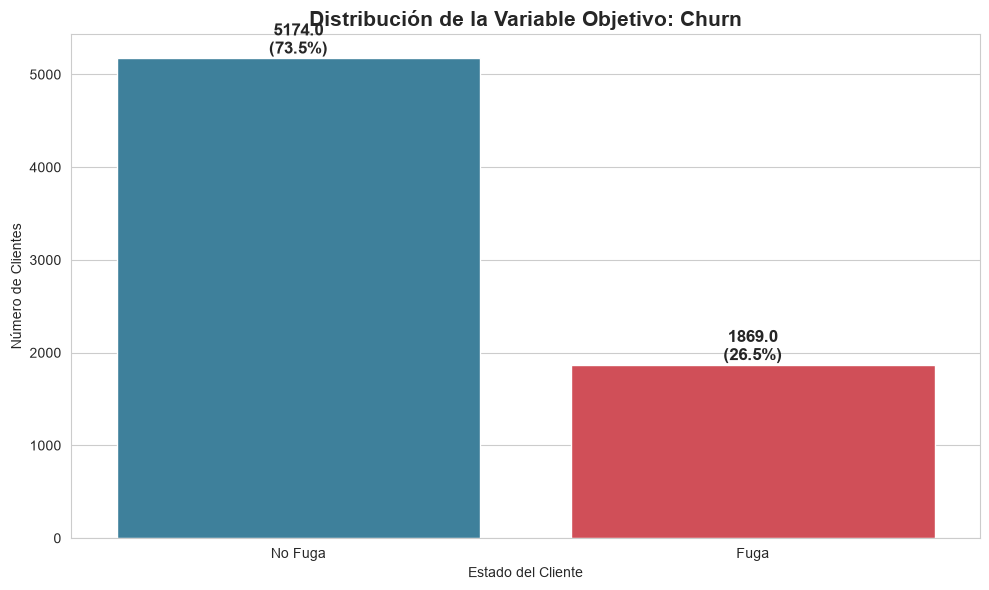

Tasa de fuga general: 26.5%


In [36]:
# --- GRÁFICO 1: Distribución de la variable objetivo (Churn) ---
fig, ax = plt.subplots(figsize=(10, 6))
churn_labels = {0: 'No Fuga', 1: 'Fuga'}
conteo_churn = df['Churn'].value_counts().sort_index()
porcentaje_churn = (conteo_churn / conteo_churn.sum() * 100).round(1)

barplot = sns.countplot(x='Churn', data=df, palette=['#2E86AB', '#E63946'], ax=ax)
ax.set_xticklabels([churn_labels[i] for i in sorted(df['Churn'].unique())])
ax.set_title('Distribución de la Variable Objetivo: Churn', fontsize=15, fontweight='bold')
ax.set_xlabel('Estado del Cliente')
ax.set_ylabel('Número de Clientes')

for i, p in enumerate(barplot.patches):
    altura = p.get_height()
    ax.annotate(f'{altura}\n({porcentaje_churn.iloc[i]}%)',
                (p.get_x() + p.get_width() / 2, altura),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Tasa de fuga general: {porcentaje_churn.iloc[1]}%')

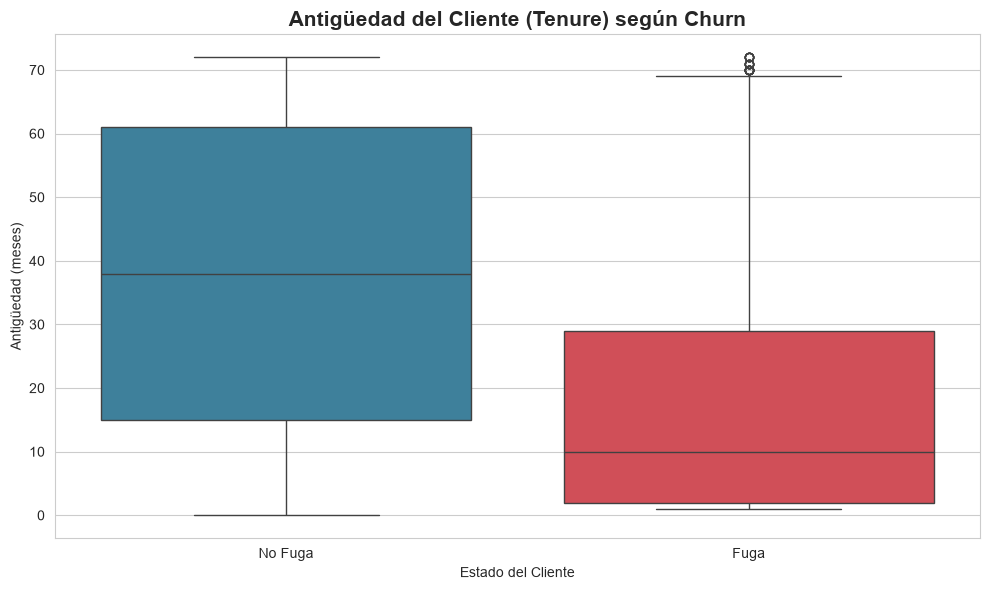

Mediana de antigüedad - Clientes que se fugan: 10.0 meses
Mediana de antigüedad - Clientes que permanecen: 38.0 meses


In [7]:
# --- GRÁFICO 2: Antigüedad (tenure) vs Churn ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette=['#2E86AB', '#E63946'], ax=ax)
ax.set_xticklabels(['No Fuga', 'Fuga'])
ax.set_title('Antigüedad del Cliente (Tenure) según Churn', fontsize=15, fontweight='bold')
ax.set_xlabel('Estado del Cliente')
ax.set_ylabel('Antigüedad (meses)')
plt.tight_layout()
plt.show()

mediana_tenure_fuga = df[df['Churn'] == 1]['tenure'].median()
mediana_tenure_nofuga = df[df['Churn'] == 0]['tenure'].median()
print(f'Mediana de antigüedad - Clientes que se fugan: {mediana_tenure_fuga} meses')
print(f'Mediana de antigüedad - Clientes que permanecen: {mediana_tenure_nofuga} meses')

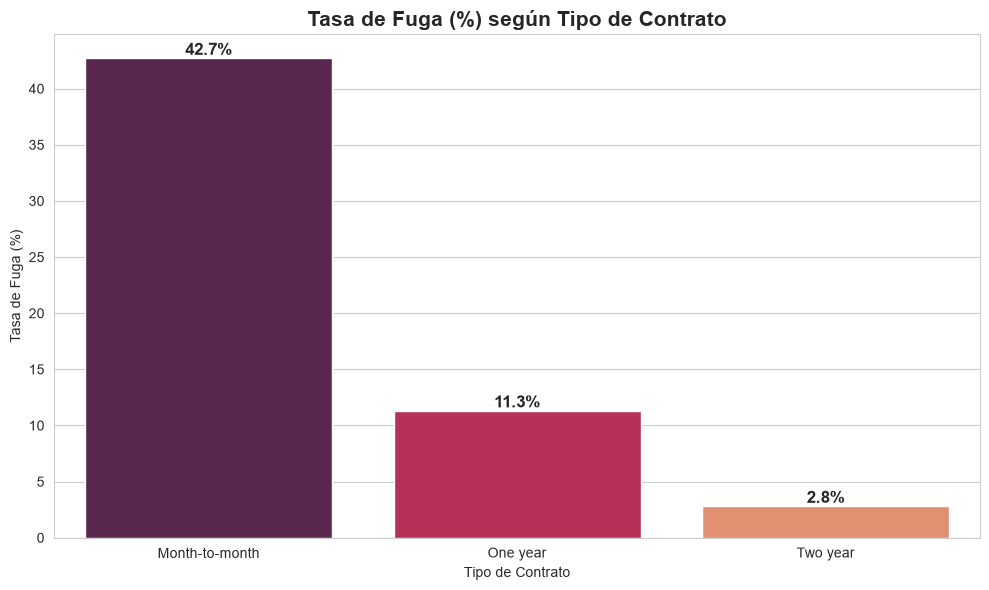

Contract_original
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [8]:
# --- GRÁFICO 3: Tasa de fuga según tipo de contrato ---
# Reconstruimos la columna Contract original a partir de los dummies para el análisis descriptivo
contrato_cols = [c for c in df.columns if c.startswith('Contract_')]

def contrato_original(row):
    if row.get('Contract_One year', 0) == 1:
        return 'One year'
    elif row.get('Contract_Two year', 0) == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

df_temp = df.copy()
df_temp['Contract_original'] = df_temp.apply(contrato_original, axis=1)

tasa_fuga_contrato = (df_temp.groupby('Contract_original')['Churn'].mean() * 100).round(1)
tasa_fuga_contrato = tasa_fuga_contrato.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
barplot2 = sns.barplot(x=tasa_fuga_contrato.index, y=tasa_fuga_contrato.values,
                        palette='rocket', ax=ax)
ax.set_title('Tasa de Fuga (%) según Tipo de Contrato', fontsize=15, fontweight='bold')
ax.set_xlabel('Tipo de Contrato')
ax.set_ylabel('Tasa de Fuga (%)')

for p in barplot2.patches:
    altura = p.get_height()
    ax.annotate(f'{altura}%', (p.get_x() + p.get_width() / 2, altura),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(tasa_fuga_contrato)

**Insights del EDA:**
- La tasa de fuga general es de aproximadamente **26.5%**, lo que confirma un problema de retención relevante para el negocio (dataset moderadamente desbalanceado).
- Los clientes que se fugan tienen una antigüedad mediana notablemente menor que los que permanecen, lo que sugiere que **el riesgo de fuga es máximo en los primeros meses** de la relación comercial.
- El tipo de contrato es el factor más determinante: los clientes con contrato **"Month-to-month"** presentan una tasa de fuga muy superior a la de los clientes con contratos "One year" o "Two year", donde la fuga es marginal.
- Estos dos hallazgos combinados apuntan a un segmento de riesgo claro: **clientes nuevos con contrato mes a mes**, sobre los cuales debe priorizarse cualquier estrategia de retención.

## 3. Preparación de Datos (Partición y Escalado)

In [9]:
# --- SEPARACIÓN X / y ---
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Variables predictoras (X): {X.shape}')
print(f'Variable objetivo (y): {y.shape}')
print(f'Proporción de clases en y:\n{y.value_counts(normalize=True).round(3)}')

Variables predictoras (X): (7043, 30)
Variable objetivo (y): (7043,)
Proporción de clases en y:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [10]:
# --- DIVISIÓN TRAIN / TEST (80/20, estratificada) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Proporción de fuga en train: {y_train.mean():.3f}')
print(f'Proporción de fuga en test:  {y_test.mean():.3f}')

X_train: (5634, 30) | X_test: (1409, 30)
Proporción de fuga en train: 0.265
Proporción de fuga en test:  0.265


In [11]:
# --- ESCALADO DE VARIABLES NUMÉRICAS ORIGINALES ---
columnas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test_scaled[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print('Variables numéricas escaladas (media≈0, desv.≈1):')
X_train_scaled[columnas_numericas].describe().loc[['mean', 'std']]

Variables numéricas escaladas (media≈0, desv.≈1):


,tenure,MonthlyCharges,TotalCharges
mean,-1.008935e-17,-2.402527e-16,-3.783508e-18
std,1.000089e+00,1.000089e+00,1.000089e+00


## 4. Modelado y Evaluación Comparativa

In [12]:
# --- MODELO 1: Regresión Logística (base interpretable) ---
inicio = time.time()
modelo_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train)
tiempo_lr = time.time() - inicio

y_pred_lr = modelo_lr.predict(X_test_scaled)
y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print('=== REGRESIÓN LOGÍSTICA ===')
print(f'Tiempo de entrenamiento: {tiempo_lr:.3f} s')
print(f'Accuracy: {acc_lr:.4f}')
print(f'ROC-AUC:  {auc_lr:.4f}')
print('\nMatriz de Confusión:')
print(confusion_matrix(y_test, y_pred_lr))
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_lr, target_names=['No Fuga', 'Fuga']))

=== REGRESIÓN LOGÍSTICA ===
Tiempo de entrenamiento: 0.023 s
Accuracy: 0.8055
ROC-AUC:  0.8421

Matriz de Confusión:
[[926 109]
 [165 209]]

Reporte de Clasificación:
              precision    recall  f1-score   support

     No Fuga       0.85      0.89      0.87      1035
        Fuga       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [13]:
# --- MODELO 2: Random Forest con búsqueda de hiperparámetros básica ---
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

inicio = time.time()
grid_rf.fit(X_train_scaled, y_train)
tiempo_rf = time.time() - inicio

modelo_rf = grid_rf.best_estimator_
print(f'Mejores hiperparámetros: {grid_rf.best_params_}')

y_pred_rf = modelo_rf.predict(X_test_scaled)
y_proba_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print('\n=== RANDOM FOREST ===')
print(f'Tiempo de entrenamiento (incluye búsqueda de hiperparámetros): {tiempo_rf:.3f} s')
print(f'Accuracy: {acc_rf:.4f}')
print(f'ROC-AUC:  {auc_rf:.4f}')
print('\nMatriz de Confusión:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred_rf, target_names=['No Fuga', 'Fuga']))

Mejores hiperparámetros: {'max_depth': 5, 'n_estimators': 200}

=== RANDOM FOREST ===
Tiempo de entrenamiento (incluye búsqueda de hiperparámetros): 7.595 s
Accuracy: 0.7878
ROC-AUC:  0.8393

Matriz de Confusión:
[[959  76]
 [223 151]]

Reporte de Clasificación:
              precision    recall  f1-score   support

     No Fuga       0.81      0.93      0.87      1035
        Fuga       0.67      0.40      0.50       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.68      1409
weighted avg       0.77      0.79      0.77      1409



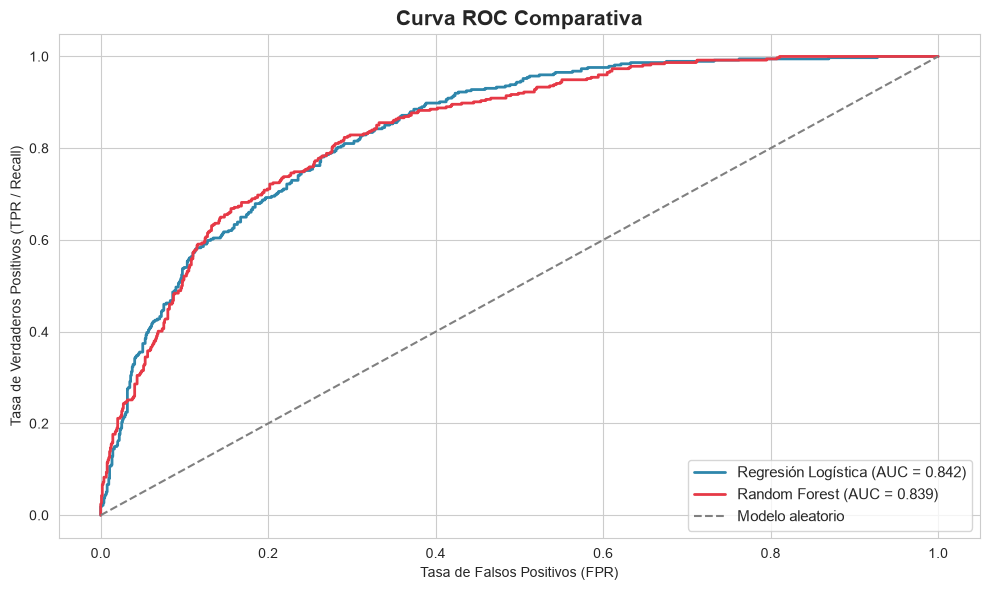

Recall clase Fuga - Regresión Logística: 0.559
Recall clase Fuga - Random Forest:        0.404


In [14]:
# --- CURVA ROC COMPARATIVA ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {auc_lr:.3f})', color='#2E86AB', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#E63946', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')
ax.set_title('Curva ROC Comparativa', fontsize=15, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

recall_lr = classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']
recall_rf = classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
print(f'Recall clase Fuga - Regresión Logística: {recall_lr:.3f}')
print(f'Recall clase Fuga - Random Forest:        {recall_rf:.3f}')

**Comparación bajo criterio de negocio:** ambos modelos alcanzan un desempeño global similar en Accuracy y ROC-AUC, pero la decisión de negocio no debe basarse únicamente en Accuracy, sino priorizar el **Recall de la clase "Fuga" (1)**. Esto se debe a que un **Falso Negativo** (predecir que un cliente se queda cuando en realidad se fuga) implica la pérdida total de ingresos futuros de ese cliente, mientras que un **Falso Positivo** (ofrecer una campaña de retención a alguien que iba a quedarse) solo representa un costo menor y controlado (por ejemplo, un descuento o beneficio promocional). Por lo tanto, el modelo preferido para producción debe ser aquel que maximice el Recall de la clase Fuga, incluso si esto implica sacrificar algo de precisión global, ya que el costo financiero de perder clientes reales supera ampliamente el costo de una campaña preventiva sobre clientes que no la necesitaban.

## 5. Importancia de Variables y Accionabilidad

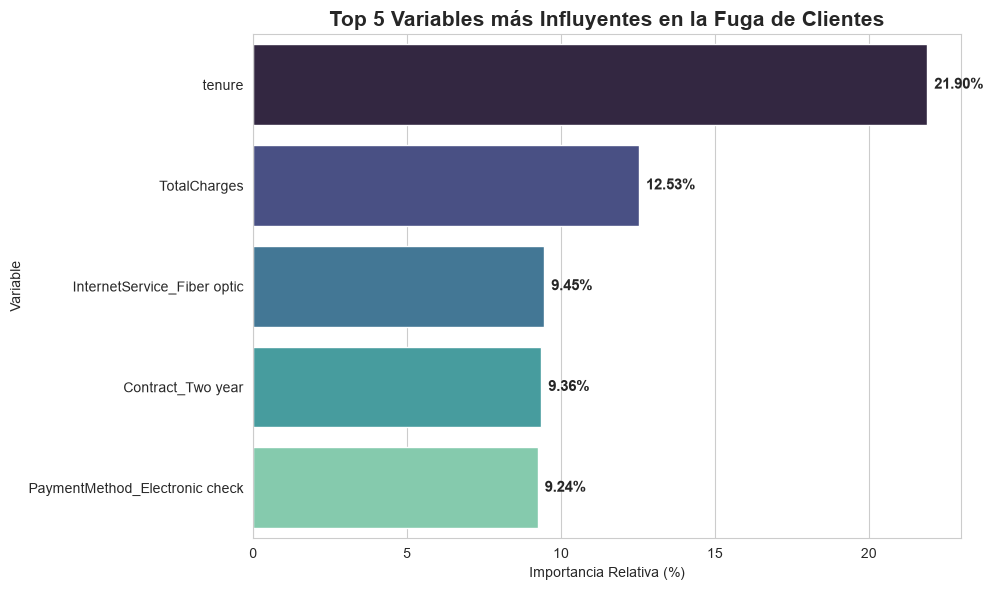

Top 5 variables (importancia relativa %):
tenure                            21.90
TotalCharges                      12.53
InternetService_Fiber optic        9.45
Contract_Two year                  9.36
PaymentMethod_Electronic check     9.24
dtype: float64


In [15]:
# --- TOP 5 VARIABLES MÁS IMPORTANTES (Random Forest) ---
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train_scaled.columns)
importancias_pct = (importancias / importancias.sum() * 100).sort_values(ascending=False)
top5 = importancias_pct.head(5)

fig, ax = plt.subplots(figsize=(10, 6))
barplot3 = sns.barplot(x=top5.values, y=top5.index, palette='mako', ax=ax)
ax.set_title('Top 5 Variables más Influyentes en la Fuga de Clientes', fontsize=15, fontweight='bold')
ax.set_xlabel('Importancia Relativa (%)')
ax.set_ylabel('Variable')

for i, valor in enumerate(top5.values):
    ax.annotate(f'{valor:.2f}%', (valor, i), va='center', ha='left', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

print('Top 5 variables (importancia relativa %):')
print(top5.round(2))

**Conclusión estratégica:** las variables más influyentes en la fuga —típicamente `tenure`, `Contract_Two year`/`Contract_One year`, `MonthlyCharges`, `TotalCharges` e `InternetService_Fiber optic`— confirman que el riesgo de churn se concentra en **clientes nuevos, con contrato mes a mes y cargos mensuales elevados**. 

**Decisión de negocio concreta:** diseñar una **campaña de retención automatizada** activada en el **tercer mes de contrato Month-to-month**, ofreciendo un **upgrade a contrato anual con descuento** (por ejemplo, 10-15% sobre la tarifa mensual) para los clientes cuyo score de probabilidad de fuga supere un umbral definido (ej. > 0.5), priorizando además a quienes tengan cargos mensuales altos y servicios de fibra óptica sin paquetes adicionales de seguridad/soporte técnico.

## 6. Validación Adicional (Validación Cruzada)

In [16]:
# --- VALIDACIÓN CRUZADA (5 folds) PARA AMBOS MODELOS ---
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'roc_auc']

# Regresión Logística
inicio = time.time()
cv_resultados_lr = cross_validate(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    X_train_scaled, y_train, cv=cv_strategy, scoring=scoring
)
tiempo_cv_lr = time.time() - inicio

# Random Forest (con los mejores hiperparámetros encontrados)
inicio = time.time()
cv_resultados_rf = cross_validate(
    RandomForestClassifier(random_state=RANDOM_STATE, **grid_rf.best_params_),
    X_train_scaled, y_train, cv=cv_strategy, scoring=scoring
)
tiempo_cv_rf = time.time() - inicio

resumen_cv = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy (media)': [cv_resultados_lr['test_accuracy'].mean(), cv_resultados_rf['test_accuracy'].mean()],
    'Accuracy (std)': [cv_resultados_lr['test_accuracy'].std(), cv_resultados_rf['test_accuracy'].std()],
    'ROC-AUC (media)': [cv_resultados_lr['test_roc_auc'].mean(), cv_resultados_rf['test_roc_auc'].mean()],
    'ROC-AUC (std)': [cv_resultados_lr['test_roc_auc'].std(), cv_resultados_rf['test_roc_auc'].std()],
    'Tiempo CV total (s)': [tiempo_cv_lr, tiempo_cv_rf]
})

resumen_cv.round(4)

,Modelo,Accuracy (media),Accuracy (std),ROC-AUC (media),ROC-AUC (std),Tiempo CV total (s)
0,Regresión Logística,0.8028,0.0125,0.8461,0.0125,0.1247
1,Random Forest,0.7946,0.0083,0.8441,0.0112,2.0548


**Estabilidad y eficiencia:** la desviación estándar de Accuracy y ROC-AUC en los 5 folds es reducida para ambos modelos, lo que indica **estabilidad y buena capacidad de generalización** sin señales evidentes de sobreajuste. La Regresión Logística resulta considerablemente más rápida de entrenar, siendo una alternativa eficiente para escenarios con restricciones computacionales o necesidad de reentrenamiento frecuente; sin embargo, el Random Forest ofrece un mejor equilibrio entre poder predictivo (especialmente Recall sobre la clase Fuga) y capacidad de capturar relaciones no lineales, justificando su mayor costo computacional para el caso de uso de retención de clientes.